# 🙋 Lesson 10 · Human-in-the-Loop（HITL）

> **人在回路**：`interrupt` 暂停等人工审批，再用 `Command(resume=...)` 恢复。

本课你会学到：
- HITL 必须配合 Checkpoint（否则中断后无法恢复）
- `interrupt(...)` 如何把控制权交给人
- `Command(resume=...)` 如何把审批结果灌回图

模型：**DeepSeek V4 Flash**（`deepseek-v4-flash`）。`.env` 需配置 `DEEPSEEK_API_KEY`（可选 `DEEPSEEK_BASE_URL`）。


## 逻辑总览

```mermaid
%%{init: {
  "theme": "base",
  "themeVariables": {
    "fontSize": "13px",
    "fontFamily": "ui-sans-serif, system-ui",
    "primaryTextColor": "#0f172a",
    "lineColor": "#94a3b8"
  }
}}%%
flowchart TB
    S([START]) --> C[chat_node]
    C --> I{interrupt<br/>审批?}
    I -->|denied| E([END / 拒绝])
    I -->|approved| LLM[deepseek-v4-flash 作答]
    LLM --> E2([END])

    CP[(Checkpointer<br/>thread_id)] -.-> C
    CP -.-> LLM


    classDef input fill:#BFDBFE,stroke:#3B82F6,color:#1E3A8A,stroke-width:2px
    classDef llm fill:#FED7AA,stroke:#F97316,color:#9A3412,stroke-width:2px
    classDef branch fill:#E9D5FF,stroke:#A855F7,color:#6B21A8,stroke-width:2px
    classDef tool fill:#BBF7D0,stroke:#22C55E,color:#14532D,stroke-width:2px
    classDef output fill:#FECACA,stroke:#F87171,color:#7F1D1D,stroke-width:2px
    class S input
    class C tool
    class I branch
    class LLM llm
    class CP tool
    class E,E2 output
```


**要点：** HITL = 中断 + 人工输入 + 恢复；依赖持久化线程状态。



# Imports

`interrupt` / `Command` 来自 `langgraph.types`；必须配合 Checkpointer。


In [20]:
from typing import Annotated, TypedDict

from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage, HumanMessage, BaseMessage
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt


In [21]:
load_dotenv()

True

In [22]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL", "https://api.deepseek.com")

llm = ChatOpenAI(
    model=os.getenv("DEEPSEEK_MODEL", "deepseek-v4-flash"),
    temperature=0,
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    timeout=120,
    max_tokens=1200,
    max_retries=1,
    extra_body={"thinking": {"type": "disabled"}},
)

# 定义 State（消息列表）


In [23]:
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

# Node — chat_node

内部调用 `interrupt` 等待人工批准，再决定是否调用 LLM。


In [24]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}



interrupt其实就是写在节点里的中断，我这么画是为了好看

# 编译图（必须带 Checkpointer）


## 逻辑总览

```mermaid
%%{init: {
  "theme": "base",
  "themeVariables": {
    "fontSize": "13px",
    "fontFamily": "ui-sans-serif, system-ui",
    "primaryTextColor": "#0f172a",
    "lineColor": "#94a3b8"
  }
}}%%
flowchart TB
    S([START]) --> C[chat_node]
    C --> I{interrupt<br/>审批?}
    I -->|denied| E([END / 拒绝])
    I -->|approved| LLM[deepseek-v4-flash 作答]
    LLM --> E2([END])

    CP[(Checkpointer<br/>thread_id)] -.-> C
    CP -.-> LLM


    classDef input fill:#BFDBFE,stroke:#3B82F6,color:#1E3A8A,stroke-width:2px
    classDef llm fill:#FED7AA,stroke:#F97316,color:#9A3412,stroke-width:2px
    classDef branch fill:#E9D5FF,stroke:#A855F7,color:#6B21A8,stroke-width:2px
    classDef tool fill:#BBF7D0,stroke:#22C55E,color:#14532D,stroke-width:2px
    classDef output fill:#FECACA,stroke:#F87171,color:#7F1D1D,stroke-width:2px
    class S input
    class C tool
    class I branch
    class LLM llm
    class CP tool
    class E,E2 output
```


**要点：** HITL = 中断 + 人工输入 + 恢复；依赖持久化线程状态。



In [25]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

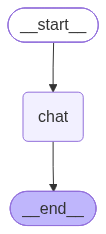

In [26]:
app

In [27]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}


# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "用非常简单的话解释一下梯度下降。")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)
    

这次 Graph 以什么身份、在哪条会话上运行，config就是执行配置

In [28]:
result

{'messages': [HumanMessage(content='用非常简单的话解释一下梯度下降。', additional_kwargs={}, response_metadata={}, id='f3eb6e55-ebd2-4ae8-aa37-73b6eb347ad4')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': '用非常简单的话解释一下梯度下降。', 'instruction': 'Approve this question? yes/no'}, id='f8a8a206ac9eb663029e794091a840f3')]}

In [29]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': '用非常简单的话解释一下梯度下降。',
 'instruction': 'Approve this question? yes/no'}

In [31]:
# Cursor/VS Code 的 Notebook 里 input() 经常弹不出输入框，会一直卡住。
# 演示 HITL 时直接赋值即可；要拒绝就改成 "no"。
print("Backend message:", message)
user_input = "yes"  # 改成 "no" 可走拒绝分支
print("人工审批结果:", user_input)

Backend message: {'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': '用非常简单的话解释一下梯度下降。', 'instruction': 'Approve this question? yes/no'}
人工审批结果: yes


# resume — 批准或拒绝

用 `Command(resume=...)` 继续同一 `thread_id`。


In [12]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [13]:
print(final_result["messages"][-1].content)

我们可以用一个**下山**的例子来理解。

想象你站在一座山上，周围全是雾，你只能看到脚下的一小块地方。你的目标是走到山脚（最低点）。

**梯度下降就是：**

1.  **看看脚下**：感觉一下哪个方向是**往下**最陡的。
2.  **迈一小步**：朝那个最陡的方向走一步。
3.  **重复**：到了新位置，再看看脚下，重新找最陡的下坡方向，再走一小步。

一直重复这个过程，直到你走到一个地方，感觉脚下是平的（怎么走都是上坡），那你就到山脚了。

---

**用电脑的话说：**

-   **山** = 一个“误差函数”（衡量模型错得有多离谱）。
-   **山脚** = 误差最小的点（模型最准的时候）。
-   **最陡的方向** = 数学上的“梯度”（也就是斜率）。
-   **迈一小步** = 更新参数（学习率，步子太大容易摔，太小走得慢）。

**总结成一句话：**
**不停地沿着“误差下降最快”的方向，小步调整参数，直到误差最小。**


In [14]:
final_result["messages"]

[HumanMessage(content='用非常简单的话解释一下梯度下降。', additional_kwargs={}, response_metadata={}, id='ce86bdc0-43b3-4103-b52d-0ee3783bb21f'),
 AIMessage(content='我们可以用一个**下山**的例子来理解。\n\n想象你站在一座山上，周围全是雾，你只能看到脚下的一小块地方。你的目标是走到山脚（最低点）。\n\n**梯度下降就是：**\n\n1.  **看看脚下**：感觉一下哪个方向是**往下**最陡的。\n2.  **迈一小步**：朝那个最陡的方向走一步。\n3.  **重复**：到了新位置，再看看脚下，重新找最陡的下坡方向，再走一小步。\n\n一直重复这个过程，直到你走到一个地方，感觉脚下是平的（怎么走都是上坡），那你就到山脚了。\n\n---\n\n**用电脑的话说：**\n\n-   **山** = 一个“误差函数”（衡量模型错得有多离谱）。\n-   **山脚** = 误差最小的点（模型最准的时候）。\n-   **最陡的方向** = 数学上的“梯度”（也就是斜率）。\n-   **迈一小步** = 更新参数（学习率，步子太大容易摔，太小走得慢）。\n\n**总结成一句话：**\n**不停地沿着“误差下降最快”的方向，小步调整参数，直到误差最小。**', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 245, 'prompt_tokens': 12, 'total_tokens': 257, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 12}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-fla

In [15]:
# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "讲大灰狼的故事。")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)
    

In [16]:
final_result = app.invoke(
    Command(resume={"approved": "no"}),
    config=config,
)

In [17]:
final_result["messages"]

[HumanMessage(content='用非常简单的话解释一下梯度下降。', additional_kwargs={}, response_metadata={}, id='ce86bdc0-43b3-4103-b52d-0ee3783bb21f'),
 AIMessage(content='我们可以用一个**下山**的例子来理解。\n\n想象你站在一座山上，周围全是雾，你只能看到脚下的一小块地方。你的目标是走到山脚（最低点）。\n\n**梯度下降就是：**\n\n1.  **看看脚下**：感觉一下哪个方向是**往下**最陡的。\n2.  **迈一小步**：朝那个最陡的方向走一步。\n3.  **重复**：到了新位置，再看看脚下，重新找最陡的下坡方向，再走一小步。\n\n一直重复这个过程，直到你走到一个地方，感觉脚下是平的（怎么走都是上坡），那你就到山脚了。\n\n---\n\n**用电脑的话说：**\n\n-   **山** = 一个“误差函数”（衡量模型错得有多离谱）。\n-   **山脚** = 误差最小的点（模型最准的时候）。\n-   **最陡的方向** = 数学上的“梯度”（也就是斜率）。\n-   **迈一小步** = 更新参数（学习率，步子太大容易摔，太小走得慢）。\n\n**总结成一句话：**\n**不停地沿着“误差下降最快”的方向，小步调整参数，直到误差最小。**', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 245, 'prompt_tokens': 12, 'total_tokens': 257, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 12}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-fla

In [18]:
app.get_state_history(config)

<generator object Pregel.get_state_history at 0x11c6597a0>

In [19]:
app.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='用非常简单的话解释一下梯度下降。', additional_kwargs={}, response_metadata={}, id='ce86bdc0-43b3-4103-b52d-0ee3783bb21f'), AIMessage(content='我们可以用一个**下山**的例子来理解。\n\n想象你站在一座山上，周围全是雾，你只能看到脚下的一小块地方。你的目标是走到山脚（最低点）。\n\n**梯度下降就是：**\n\n1.  **看看脚下**：感觉一下哪个方向是**往下**最陡的。\n2.  **迈一小步**：朝那个最陡的方向走一步。\n3.  **重复**：到了新位置，再看看脚下，重新找最陡的下坡方向，再走一小步。\n\n一直重复这个过程，直到你走到一个地方，感觉脚下是平的（怎么走都是上坡），那你就到山脚了。\n\n---\n\n**用电脑的话说：**\n\n-   **山** = 一个“误差函数”（衡量模型错得有多离谱）。\n-   **山脚** = 误差最小的点（模型最准的时候）。\n-   **最陡的方向** = 数学上的“梯度”（也就是斜率）。\n-   **迈一小步** = 更新参数（学习率，步子太大容易摔，太小走得慢）。\n\n**总结成一句话：**\n**不停地沿着“误差下降最快”的方向，小步调整参数，直到误差最小。**', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 245, 'prompt_tokens': 12, 'total_tokens': 257, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 12}, 'model_provider': 'openai